In [2]:
import numpy as np
import matplotlib.pyplot as plt
import subprocess

In [61]:
NLS = [101, 201, 301]
eps_max = [10., 15., 20.]
NGL = [2, 5, 10]

In [130]:
def make_R_values(NL, emax, NG):
    filename = "analysis/R_values-{}-{}-{}.csv".format(int(NL), int(emax), int(NG))
    result = subprocess.run("cd .. && bash script/calc_R.sh 0 {} {} {} {}".format(NL, emax, NG, filename), shell=True, capture_output=True, text=True)    

    res = result.stdout
    dndt = float(res.split('\n')[0].split('=')[1])
    drhodt = float(res.split('\n')[1].split('=')[1])

    data = np.loadtxt(filename[9:], delimiter=',')
    load = np.sum(data[-1])
    
    return [NL, emax, NG, load, dndt, drhodt]
    

In [91]:
results = []
for NL in NLS:
    for emax in eps_max:
        for NG in NGL:
            print(NL, emax, NG)
            %time results.append(make_R_values(NL, emax, NG))

101 10.0 2
CPU times: user 3.05 ms, sys: 12.6 ms, total: 15.6 ms
Wall time: 45.6 s
101 10.0 5
CPU times: user 1.59 ms, sys: 3.89 ms, total: 5.49 ms
Wall time: 49.6 s
101 10.0 10
CPU times: user 1.65 ms, sys: 3.51 ms, total: 5.16 ms
Wall time: 56.5 s
101 15.0 2
CPU times: user 1.31 ms, sys: 3.1 ms, total: 4.41 ms
Wall time: 46.9 s
101 15.0 5
CPU times: user 1.41 ms, sys: 3.13 ms, total: 4.53 ms
Wall time: 50.9 s
101 15.0 10
CPU times: user 1.4 ms, sys: 3.32 ms, total: 4.72 ms
Wall time: 57.8 s
101 20.0 2
CPU times: user 1.5 ms, sys: 3.41 ms, total: 4.91 ms
Wall time: 47.9 s
101 20.0 5
CPU times: user 1.29 ms, sys: 2.93 ms, total: 4.21 ms
Wall time: 51.4 s
101 20.0 10
CPU times: user 1.58 ms, sys: 3.16 ms, total: 4.74 ms
Wall time: 58.4 s
201 10.0 2
CPU times: user 6.77 ms, sys: 6.94 ms, total: 13.7 ms
Wall time: 5min 51s
201 10.0 5
CPU times: user 6.66 ms, sys: 6.75 ms, total: 13.4 ms
Wall time: 6min 8s
201 10.0 10
CPU times: user 6.99 ms, sys: 8.06 ms, total: 15 ms
Wall time: 6min 34s


In [132]:
for i in range(len(results)):
    if results[i][1] == 20:
        print(results[i][:3], results[i][3]/results[16][3], results[i][-2]/results[16][-2], results[i][-1]/results[16][-1])

[101, 20.0, 2] 0.12428684514481014 4.970658128423843 7.480765382061473
[101, 20.0, 5] 0.1345180665432502 3.968031618180454 5.3079858290070625
[101, 20.0, 10] 0.15221777183361193 3.9382394877054305 5.584937819665765
[201, 20.0, 2] 0.9608327897020807 1.9821472346599294 3.146259968535412
[201, 20.0, 5] 1.0 1.0 1.0
[201, 20.0, 10] 1.065071860277137 0.9999724841784026 1.316940115228781
[301, 20.0, 2] 3.2058432295107875 1.4265202491432574 2.3412754688873014
[301, 20.0, 5] 3.2926431200651103 0.44596142782099707 0.1968644093630343
[301, 20.0, 10] 3.434971235698785 0.44611651699727345 0.5142100917297439


In [4]:
e10 = np.loadtxt("R_values-201-10-5.csv", delimiter=',')
e15 = np.loadtxt("R_values-201-15-5.csv", delimiter=',')
e20 = np.loadtxt("R_values-201-20-5.csv", delimiter=',')

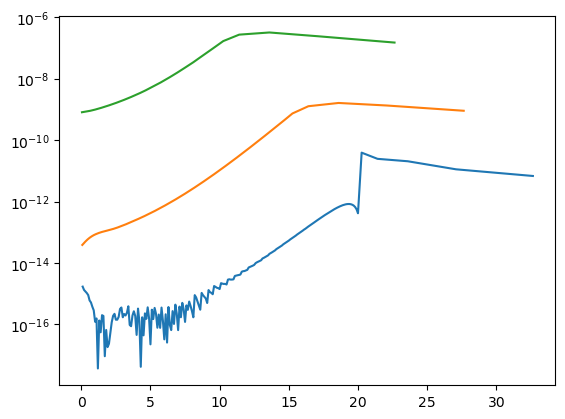

In [6]:
plt.semilogy(e20[1][1:], e20[0][1:])
plt.semilogy(e15[1][1:], e15[0][1:])
plt.semilogy(e10[1][1:], e10[0][1:])

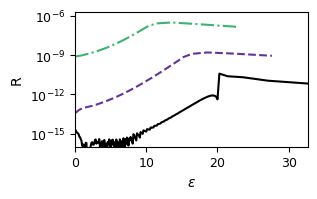

In [42]:
plt.figure(figsize=(3,1.75))
plt.semilogy(e20[1][1:], e20[0][1:], c='k')
plt.semilogy(e15[1][1:], e15[0][1:], c='rebeccapurple', ls='--')
plt.semilogy(e10[1][1:], e10[0][1:], c='mediumseagreen', ls='-.')

plt.xlabel(r"$\epsilon$", fontsize=10)
plt.ylabel("R", fontsize=10)

plt.xlim(0, np.max(e20[1]))
plt.ylim(1e-16, 2e-6)

plt.yticks([1e-15, 1e-12, 1e-9, 1e-6], fontsize=9)
plt.xticks(fontsize=9)
plt.savefig("R.pdf", bbox_inches='tight')